In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

sns.set_style("whitegrid")

import matplotlib

# set font size to 16
matplotlib.rcParams.update({"font.size": 16})

SEED = 4

In [2]:

#Use the csv files again
#Load accuracy, precision, recall and f1 score
def load_dict_from_csv(filename):
    df = pd.read_csv(filename)
    nested_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        nested_dict.setdefault(run, {})[method] = group['Value'].tolist()
    return nested_dict

def get_summary(loaded_dict, methods):
    
    summary_dict = {}
    for method in methods:
        all_runs = np.array([loaded_dict[run][method] for run in range(n_runs)]) # shape: (100, array_length)
        # Compute statistics
        mean_values = np.mean(all_runs, axis=0)
        plow_values = np.percentile(all_runs, 10, axis=0)
        phigh_values = np.percentile(all_runs, 90, axis=0)
        # Store in nested structure for easy plotting
        summary_dict[method] = {
            "mean": mean_values.tolist(),
            "plow": plow_values.tolist(),
            "phigh": phigh_values.tolist()
        }
    return summary_dict

n_runs = 100
start_types = ["Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]

all_accuracy = defaultdict(list)
all_precision = defaultdict(list)
all_recall = defaultdict(list)
all_f1score = defaultdict(list)

for start_type in start_types:

    accuracy_dict_loaded = load_dict_from_csv( f"./results_dictionaries/accuracy_dict_{start_type}_{n_runs}.csv")
    precision_dict_loaded = load_dict_from_csv( f"./results_dictionaries/precision_dict_{start_type}_{n_runs}.csv")
    recall_dict_loaded = load_dict_from_csv( f"./results_dictionaries/recall_dict_{start_type}_{n_runs}.csv")
    f1score_dict_loaded = load_dict_from_csv( f"./results_dictionaries/f1score_dict_{start_type}_{n_runs}.csv")

    methods = ["Predictproba_batch"]
    #Mean Accuracy Values
    accuracy_summary = get_summary(accuracy_dict_loaded, methods)
    # Mean Precision Values
    precision_summary = get_summary(precision_dict_loaded, methods)
    # Mean Recall Values
    recall_summary =  get_summary(recall_dict_loaded, methods)
    # Mean F1 Score Values
    f1score_summary = get_summary(f1score_dict_loaded, methods)

    all_accuracy[start_type].append(accuracy_summary[methods[0]])
    all_precision[start_type].append(precision_summary[methods[0]])
    all_recall[start_type].append(recall_summary[methods[0]])
    all_f1score[start_type].append(f1score_summary[methods[0]])

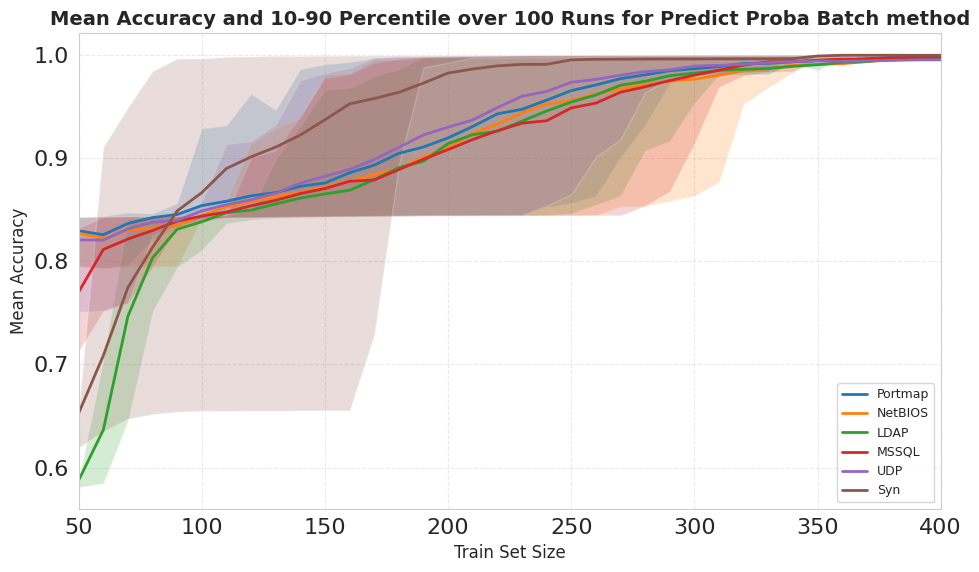

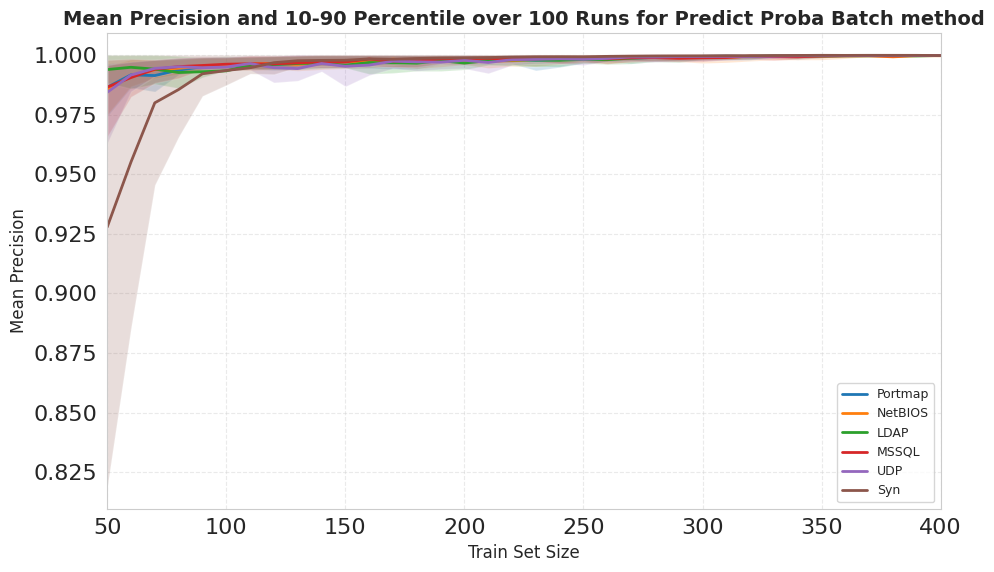

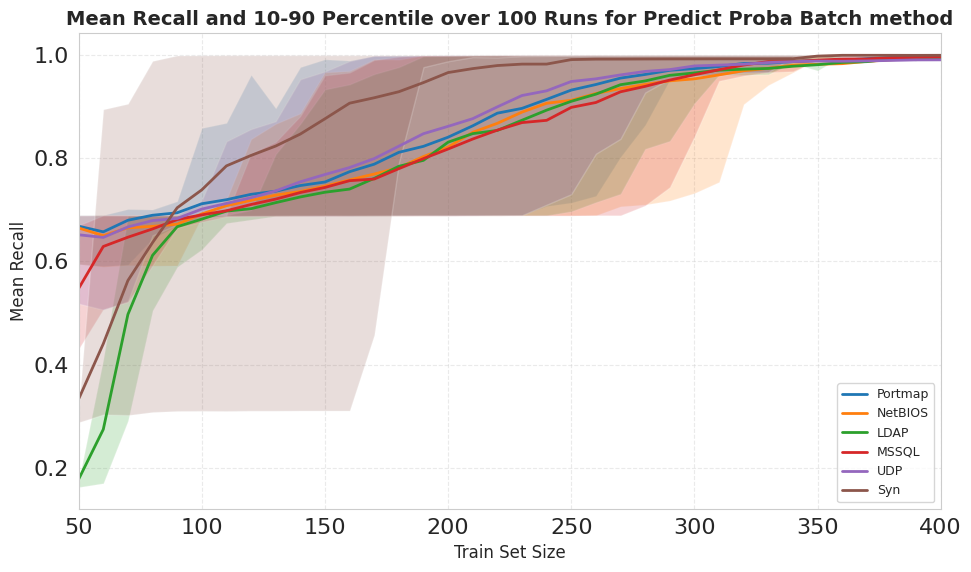

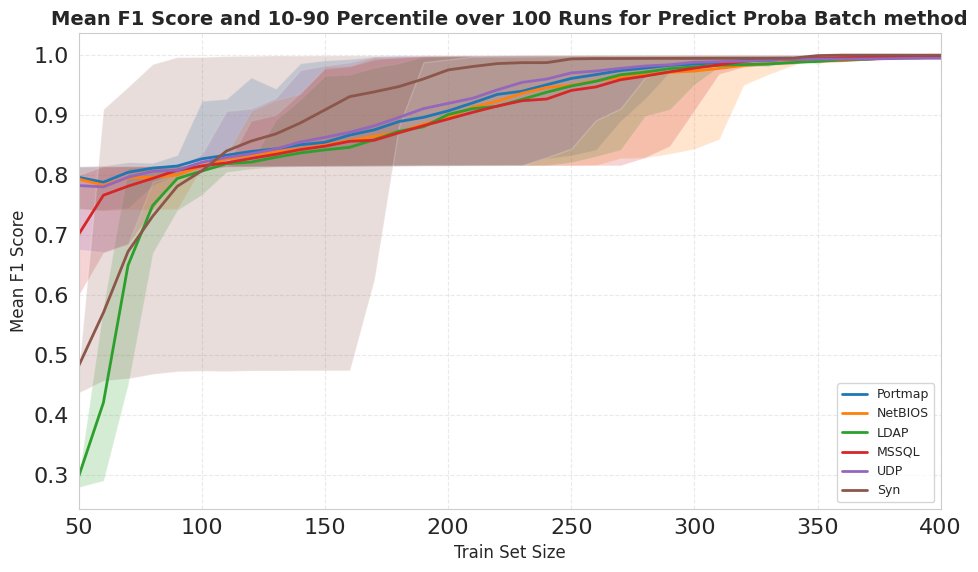

In [3]:
def plot_summary(dict_summary, metric_name):
    #dataset_size = np.array(range(50, 401))
    dataset_size = np.array(range(50, 401, 10))
    #method_label = ["KU Batch", "KU Single", "Predict Proba Batch", "Predict Proba Single", "QBC", "Random"]

    #Plot
    plt.figure(figsize=(10, 6))
    # Plot each method
    #start_types = list(dict_summary[0].keys())
    start_types = ["Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]
    for start_type in start_types:
        mean = np.array(dict_summary[start_type][0]["mean"])
        plow = np.array(dict_summary[start_type][0]["plow"])
        phigh = np.array(dict_summary[start_type][0]["phigh"])
        plt.plot(dataset_size, mean, linewidth=2, label=start_type)    
        plt.fill_between(dataset_size, plow, phigh, alpha=0.2)

    # Labels, legend, and styling
    plt.xlim(50, 400)
    plt.xlabel("Train Set Size", fontsize=12)
    plt.ylabel(f"Mean {metric_name}", fontsize=12)
    plt.title(f"Mean {metric_name} and 10-90 Percentile over 100 Runs for Predict Proba Batch method", fontsize=14, weight="bold")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# Plot summaries
plot_summary(all_accuracy, "Accuracy")
plot_summary(all_precision, "Precision")
plot_summary(all_recall, "Recall")
plot_summary(all_f1score, "F1 Score")